In [5]:
# ============================================================
#  Netflix Customer RFM Analysis — Google Colab Notebook
#  Upload your netflix_users.csv when prompted, then run all.
# ============================================================

# ── CELL 1 · Install dependencies ────────────────────────────────────────
# (matplotlib & pandas are pre-installed in Colab; this ensures versions)
# !pip install matplotlib seaborn pandas numpy --quiet

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Import the files module for uploading local files
from google.colab import files

# Upload the netflix_users.csv file from your local machine
print("Please upload the 'netflix_users.csv' file:")
uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the uploaded CSV file into a DataFrame
df = pd.read_csv(file_name)

print(f"✅ Loaded {len(df):,} rows  |  Columns: {list(df.columns)}")
display(df.head())

Please upload the 'netflix_users.csv' file:


Saving netflix_users.csv to netflix_users.csv
✅ Loaded 25,000 rows  |  Columns: ['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login']


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [10]:
# ── CELL 3 · RFM Feature Engineering

df['Last_Login'] = pd.to_datetime(df['Last_Login'])

# Reference date (adjust if your data has a different end date)
REFERENCE_DATE = pd.Timestamp('2025-03-01')

# Recency — days since last login (lower = better)
df['Recency'] = (REFERENCE_DATE - df['Last_Login']).dt.days

# Frequency — proxy: estimated sessions (watch hours / avg 2-hr session)
df['Frequency'] = np.ceil(df['Watch_Time_Hours'] / 2).astype(int)

# Monetary — annualised subscription spend
SUB_PRICE = {'Basic': 9.99, 'Standard': 15.49, 'Premium': 22.99}
df['Monthly_Spend'] = df['Subscription_Type'].map(SUB_PRICE)
df['Monetary'] = df['Monthly_Spend'] * 12

print("RFM feature stats:")
print(df[['Recency', 'Frequency', 'Monetary']].describe().round(2))

RFM feature stats:
        Recency  Frequency  Monetary
count  25000.00   25000.00  25000.00
mean     174.84     250.73    194.07
std      105.88     143.19     64.12
min       -7.00       1.00    119.88
25%       82.00     129.00    119.88
50%      175.00     251.00    185.88
75%      267.00     373.00    275.88
max      358.00     500.00    275.88


In [11]:
# ── CELL 4 · RFM Scoring (quintiles 1–5) ────────────────────────────────
# Recency: lower days = score 5  (reversed)
df['R_Score'] = pd.qcut(df['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency & Monetary: higher = score 5
df['F_Score'] = pd.qcut(
    df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)
df['M_Score'] = pd.qcut(
    df['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
df['RFM_Total'] = df['R_Score'] + df['F_Score'] + df['M_Score']

print("\nRFM Score distribution (Total):")
print(df['RFM_Total'].value_counts().sort_index())


RFM Score distribution (Total):
RFM_Total
3      214
4      572
5     1207
6     1974
7     2963
8     3655
9     3786
10    3606
11    2992
12    2034
13    1196
14     591
15     210
Name: count, dtype: int64


In [12]:
# ── CELL 5 · Segment Assignment ──────────────────────────────────────────
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f >= 3:
        return 'Promising'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Needs Attention'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r == 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

df['Segment'] = df.apply(assign_segment, axis=1)

print("\nSegment distribution:")
print(df['Segment'].value_counts().to_string())


Segment distribution:
Segment
Lost                   5540
Loyal Customers        4466
New Customers          3977
At Risk                3569
Hibernating            2066
Potential Loyalists    1788
Champions              1608
Promising              1210
Needs Attention         776


In [14]:
# ── CELL 6 · Segment Summary Table ───────────────────────────────────────
SEG_ORDER = [
    'Champions', 'Loyal Customers', 'Potential Loyalists', 'New Customers',
    'Promising', 'Needs Attention', 'At Risk', 'Hibernating', 'Lost'
]

summary = df.groupby('Segment').agg(
    Users         = ('User_ID',   'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Avg_RFM_Total = ('RFM_Total', 'mean'),
    Avg_Age       = ('Age',       'mean'),
).round(1)

summary['Pct_Share']      = (summary['Users'] / len(df) * 100).round(1)
summary['Est_Annual_Rev'] = (summary['Users'] * summary['Avg_Monetary']).astype(int)
summary = summary.reindex([s for s in SEG_ORDER if s in summary.index])

print("\n=== RFM Segment Summary ===")
print(summary.to_string())

# Optional: save enriched CSV
df.to_csv('netflix_rfm_enriched.csv', index=False)
print("\n✅ Enriched data saved to netflix_rfm_enriched.csv")


=== RFM Segment Summary ===
                     Users  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM_Total  Avg_Age  Pct_Share  Est_Annual_Rev
Segment                                                                                                                
Champions             1608         65.7          400.0         261.0           13.5     46.8        6.4          419688
Loyal Customers       4466         65.9          333.7         168.9           10.8     46.7       17.9          754307
Potential Loyalists   1788        175.1          350.1         237.1           11.0     46.6        7.2          423934
New Customers         3977         64.4          102.7         193.4            9.0     46.4       15.9          769151
Promising             1210        174.9          346.9         130.0            8.5     47.1        4.8          157300
Needs Attention        776        173.8          152.6         213.5            8.5     46.4        3.1          165676
At Risk    

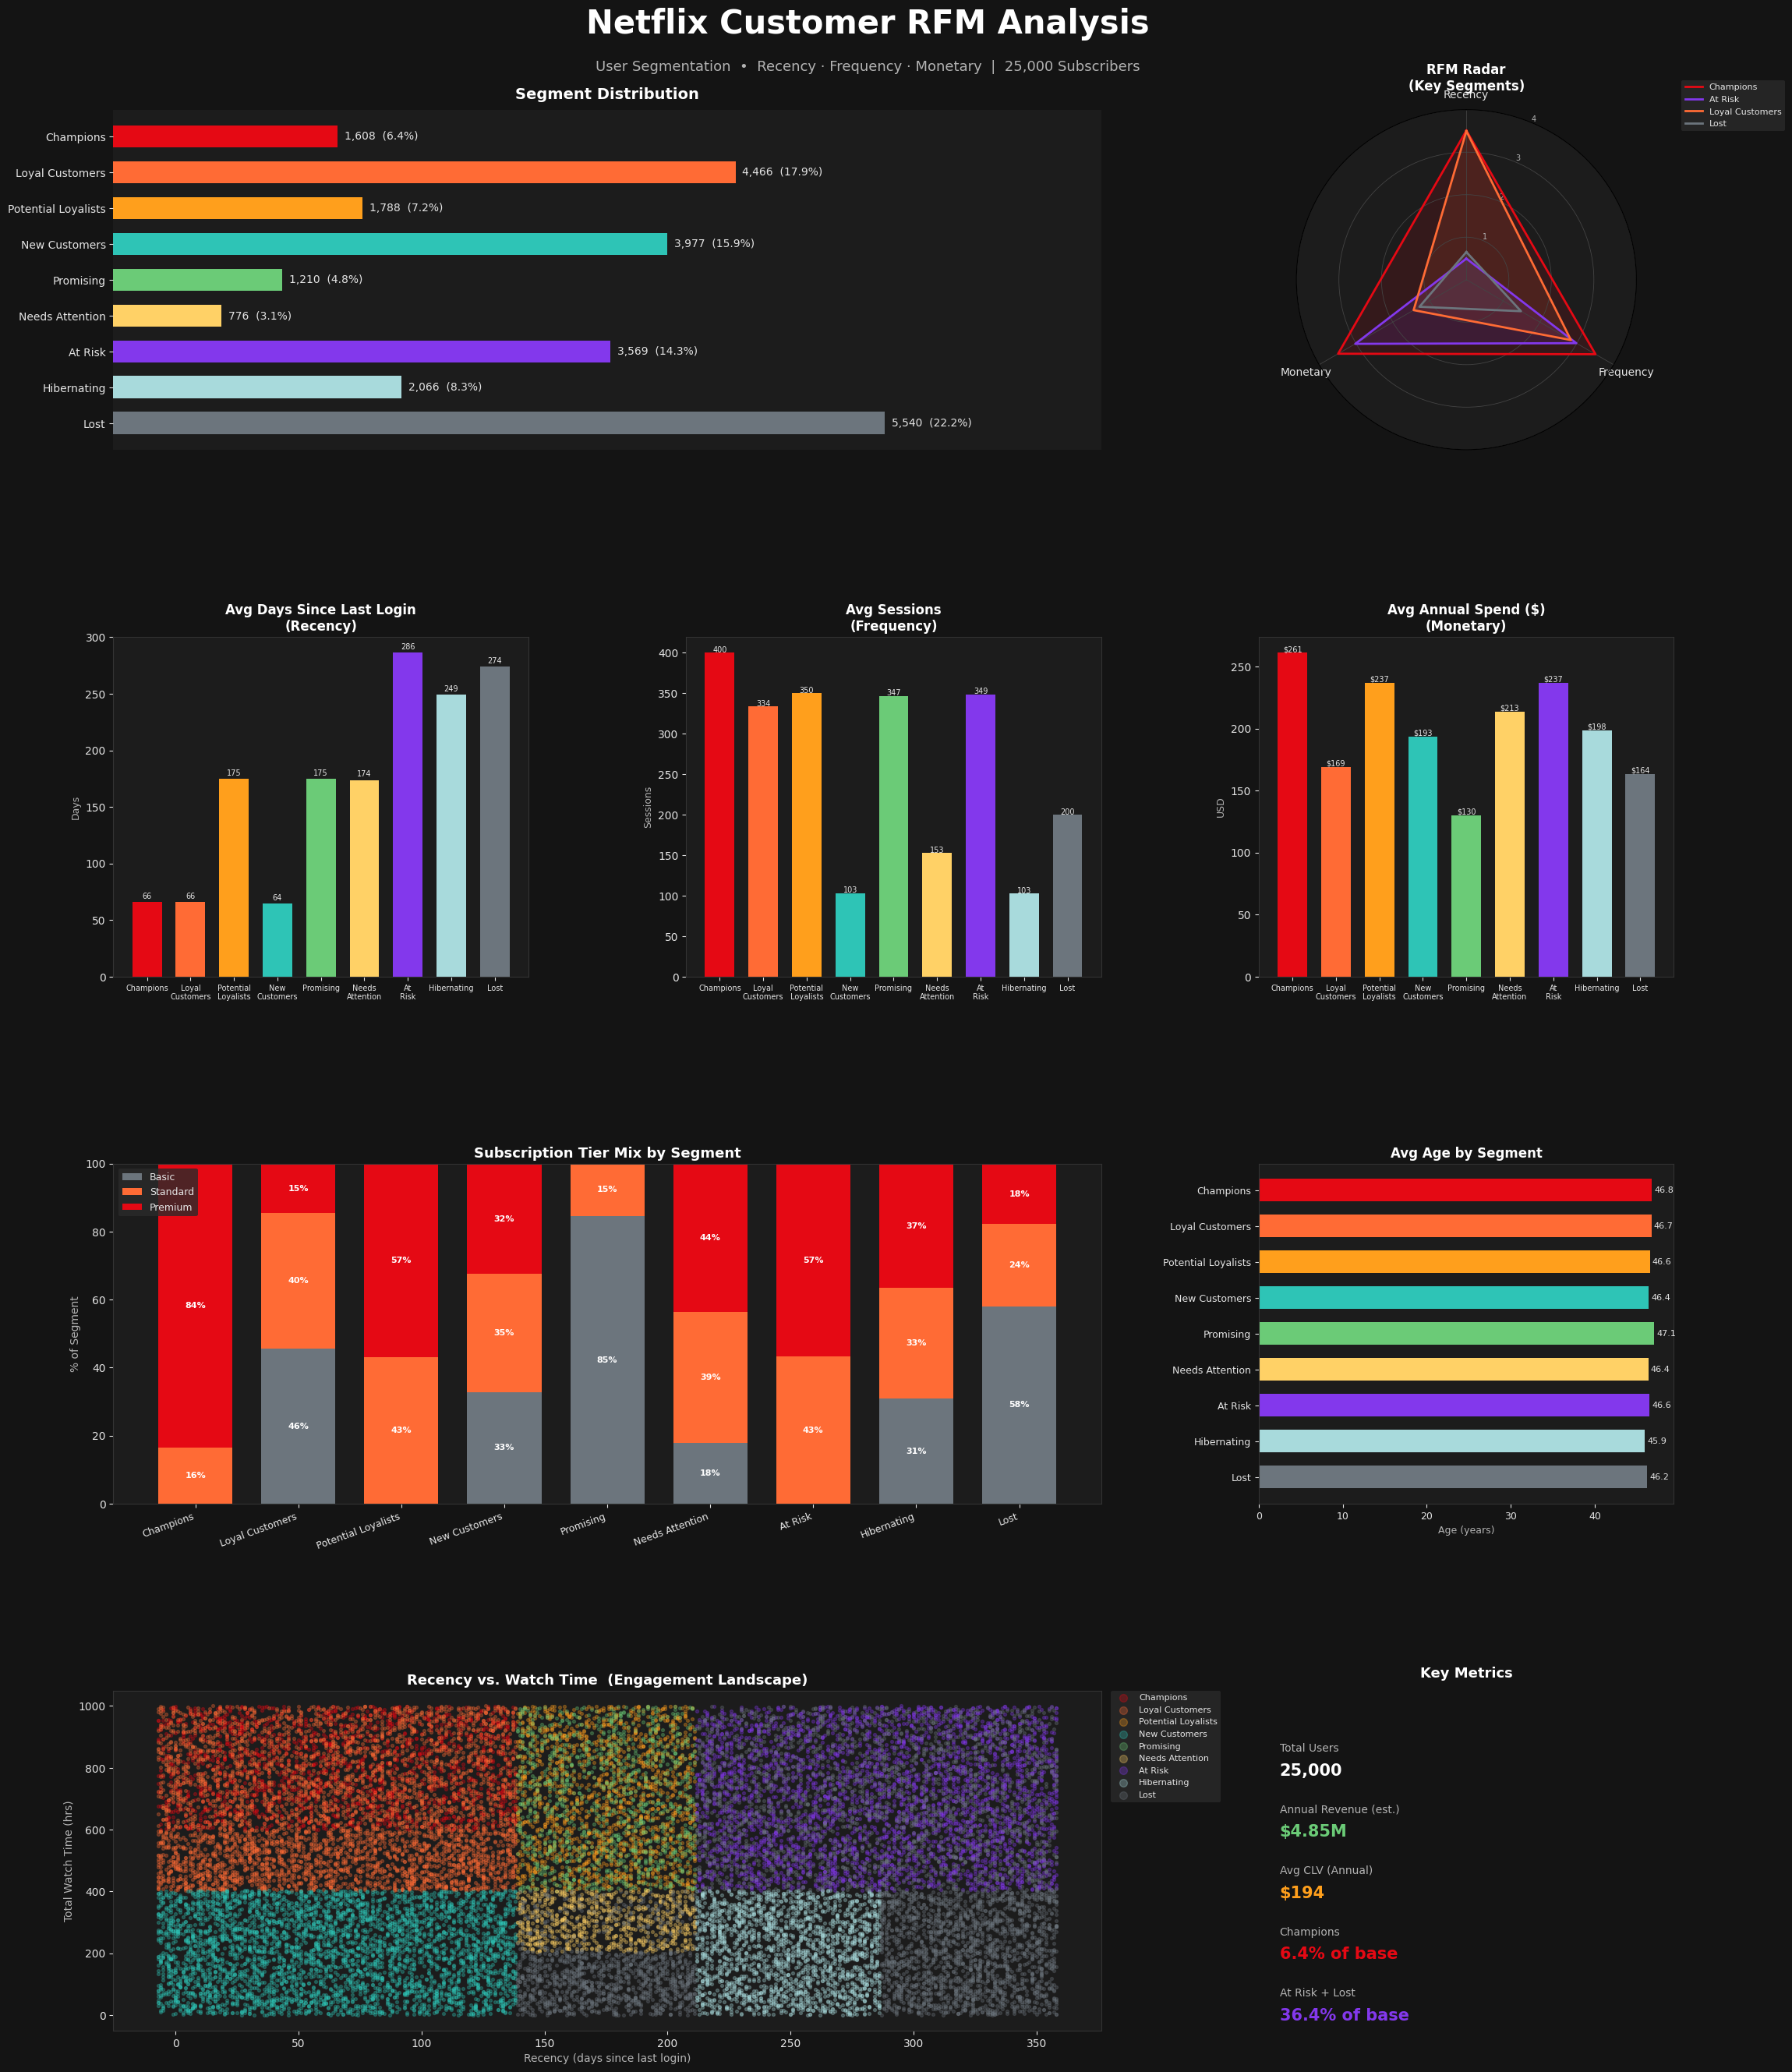

✅ Dashboard saved as netflix_rfm_dashboard.png


In [15]:
# ── CELL 7 · Dashboard Visualisation ─────────────────────────────────────
# Colour palette
SEGMENT_COLORS = {
    'Champions':           '#E50914',
    'Loyal Customers':     '#FF6B35',
    'Potential Loyalists': '#FF9F1C',
    'New Customers':       '#2EC4B6',
    'Promising':           '#6BCB77',
    'Needs Attention':     '#FFD166',
    'At Risk':             '#8338EC',
    'Hibernating':         '#A8DADC',
    'Lost':                '#6C757D',
}
NETFLIX_BLACK = '#141414'
DARK_GRAY     = '#1C1C1C'
MID_GRAY      = '#2A2A2A'
LIGHT_GRAY    = '#B3B3B3'
WHITE         = '#FFFFFF'
TEXT_MAIN     = '#E5E5E5'

seg_order     = [s for s in SEG_ORDER if s in df['Segment'].unique()]
counts        = df['Segment'].value_counts().reindex(seg_order)
colors_ord    = [SEGMENT_COLORS[s] for s in seg_order]

fig = plt.figure(figsize=(22, 28), facecolor=NETFLIX_BLACK)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38,
                        left=0.06, right=0.97, top=0.93, bottom=0.05)

fig.text(0.5, 0.965, 'Netflix Customer RFM Analysis',
         fontsize=30, fontweight='bold', ha='center', color=WHITE)
fig.text(0.5, 0.948,
         'User Segmentation  •  Recency · Frequency · Monetary  |  25,000 Subscribers',
         fontsize=13, ha='center', color=LIGHT_GRAY)

# 1. Segment distribution (horizontal bar)
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(DARK_GRAY)
bars = ax1.barh(seg_order[::-1], counts.reindex(seg_order[::-1]),
                color=[SEGMENT_COLORS[s] for s in seg_order[::-1]],
                height=0.62, edgecolor='none')
for bar, s in zip(bars, seg_order[::-1]):
    val = counts[s]
    pct = val / len(df) * 100
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f'{val:,}  ({pct:.1f}%)', va='center', color=TEXT_MAIN, fontsize=10)
ax1.set_xlim(0, counts.max() * 1.28)
ax1.set_title('Segment Distribution', color=WHITE, fontsize=14, fontweight='bold', pad=10)
ax1.tick_params(colors=TEXT_MAIN, labelsize=10)
for sp in ax1.spines.values(): sp.set_visible(False)
ax1.xaxis.set_visible(False)

# 2. RFM Radar
rfm_means = df.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].mean()
rfm_norm  = (rfm_means - 1) / 4
highlight = ['Champions', 'At Risk', 'Loyal Customers', 'Lost']
ax2 = fig.add_subplot(gs[0, 2], polar=True)
ax2.set_facecolor(DARK_GRAY)
N      = 3
labels = ['Recency', 'Frequency', 'Monetary']
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(labels, color=TEXT_MAIN, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['1', '2', '3', '4'], color=LIGHT_GRAY, fontsize=7)
ax2.grid(color='#444444', linewidth=0.6)
for seg in [s for s in highlight if s in rfm_norm.index]:
    vals = rfm_norm.loc[seg].tolist() + [rfm_norm.loc[seg].tolist()[0]]
    ax2.plot(angles, vals, color=SEGMENT_COLORS[seg], linewidth=2, label=seg)
    ax2.fill(angles, vals, color=SEGMENT_COLORS[seg], alpha=0.12)
ax2.set_title('RFM Radar\n(Key Segments)', color=WHITE, fontsize=12, fontweight='bold', pad=18)
ax2.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1),
           fontsize=8, labelcolor=TEXT_MAIN, facecolor=MID_GRAY, edgecolor='none')

# 3. Avg Recency
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(DARK_GRAY)
rec   = df.groupby('Segment')['Recency'].mean().reindex(seg_order)
bars3 = ax3.bar(range(len(seg_order)), rec.values,
                color=colors_ord, edgecolor='none', width=0.68)
ax3.set_xticks(range(len(seg_order)))
ax3.set_xticklabels([s.replace(' ', '\n') for s in seg_order],
                    color=TEXT_MAIN, fontsize=7)
ax3.set_title('Avg Days Since Last Login\n(Recency)', color=WHITE, fontsize=12, fontweight='bold')
ax3.set_ylabel('Days', color=LIGHT_GRAY, fontsize=9)
ax3.tick_params(colors=TEXT_MAIN)
for sp in ax3.spines.values(): sp.set_color('#333333')
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f'{bar.get_height():.0f}', ha='center', color=TEXT_MAIN, fontsize=7)

# 4. Avg Frequency
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(DARK_GRAY)
freq  = df.groupby('Segment')['Frequency'].mean().reindex(seg_order)
bars4 = ax4.bar(range(len(seg_order)), freq.values,
                color=colors_ord, edgecolor='none', width=0.68)
ax4.set_xticks(range(len(seg_order)))
ax4.set_xticklabels([s.replace(' ', '\n') for s in seg_order],
                    color=TEXT_MAIN, fontsize=7)
ax4.set_title('Avg Sessions\n(Frequency)', color=WHITE, fontsize=12, fontweight='bold')
ax4.set_ylabel('Sessions', color=LIGHT_GRAY, fontsize=9)
ax4.tick_params(colors=TEXT_MAIN)
for sp in ax4.spines.values(): sp.set_color('#333333')
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{bar.get_height():.0f}', ha='center', color=TEXT_MAIN, fontsize=7)

# 5. Avg Monetary
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(DARK_GRAY)
mon   = df.groupby('Segment')['Monetary'].mean().reindex(seg_order)
bars5 = ax5.bar(range(len(seg_order)), mon.values,
                color=colors_ord, edgecolor='none', width=0.68)
ax5.set_xticks(range(len(seg_order)))
ax5.set_xticklabels([s.replace(' ', '\n') for s in seg_order],
                    color=TEXT_MAIN, fontsize=7)
ax5.set_title('Avg Annual Spend ($)\n(Monetary)', color=WHITE, fontsize=12, fontweight='bold')
ax5.set_ylabel('USD', color=LIGHT_GRAY, fontsize=9)
ax5.tick_params(colors=TEXT_MAIN)
for sp in ax5.spines.values(): sp.set_color('#333333')
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'${bar.get_height():.0f}', ha='center', color=TEXT_MAIN, fontsize=7)

# 6. Subscription mix stacked bar
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor(DARK_GRAY)
sub_mix = pd.crosstab(df['Segment'], df['Subscription_Type'], normalize='index') * 100
sub_mix = sub_mix.reindex(seg_order)
sub_colors = {'Basic': '#6C757D', 'Standard': '#FF6B35', 'Premium': '#E50914'}
bottoms = np.zeros(len(seg_order))
for sub in [s for s in ['Basic', 'Standard', 'Premium'] if s in sub_mix.columns]:
    vals = sub_mix[sub].values
    ax6.bar(range(len(seg_order)), vals, bottom=bottoms,
            color=sub_colors[sub], label=sub, edgecolor='none', width=0.72)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6:
            ax6.text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                     color=WHITE, fontsize=8, fontweight='bold')
    bottoms += vals
ax6.set_xticks(range(len(seg_order)))
ax6.set_xticklabels(seg_order, color=TEXT_MAIN, fontsize=9, rotation=20, ha='right')
ax6.set_title('Subscription Tier Mix by Segment', color=WHITE, fontsize=13, fontweight='bold')
ax6.set_ylabel('% of Segment', color=LIGHT_GRAY)
ax6.tick_params(colors=TEXT_MAIN)
for sp in ax6.spines.values(): sp.set_color('#333333')
ax6.legend(facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN, fontsize=9)

# 7. Avg Age by Segment
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(DARK_GRAY)
age_seg = df.groupby('Segment')['Age'].mean().reindex(seg_order)
ax7.barh(seg_order[::-1], age_seg.reindex(seg_order[::-1]),
         color=[SEGMENT_COLORS[s] for s in seg_order[::-1]],
         height=0.62, edgecolor='none')
ax7.set_title('Avg Age by Segment', color=WHITE, fontsize=12, fontweight='bold')
ax7.set_xlabel('Age (years)', color=LIGHT_GRAY, fontsize=9)
ax7.tick_params(colors=TEXT_MAIN, labelsize=9)
for sp in ax7.spines.values(): sp.set_color('#333333')
for i, (seg, val) in enumerate(zip(seg_order[::-1],
                                   age_seg.reindex(seg_order[::-1]))):
    ax7.text(val + 0.3, i, f'{val:.1f}', va='center', color=TEXT_MAIN, fontsize=8)

# 8. Recency vs Watch Time scatter
ax8 = fig.add_subplot(gs[3, :2])
ax8.set_facecolor(DARK_GRAY)
for seg in seg_order:
    sdf = df[df['Segment'] == seg]
    ax8.scatter(sdf['Recency'], sdf['Watch_Time_Hours'],
                c=SEGMENT_COLORS[seg], alpha=0.3, s=8, label=seg)
ax8.set_xlabel('Recency (days since last login)', color=LIGHT_GRAY, fontsize=10)
ax8.set_ylabel('Total Watch Time (hrs)', color=LIGHT_GRAY, fontsize=10)
ax8.set_title('Recency vs. Watch Time  (Engagement Landscape)',
              color=WHITE, fontsize=13, fontweight='bold')
ax8.tick_params(colors=TEXT_MAIN)
for sp in ax8.spines.values(): sp.set_color('#333333')
ax8.legend(facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN,
           fontsize=8, markerscale=2.5,
           bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# 9. KPI scorecard
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor(MID_GRAY)
ax9.axis('off')
total_rev   = df['Monetary'].sum()
champ_share = len(df[df['Segment'] == 'Champions']) / len(df) * 100
risk_share  = len(df[df['Segment'].isin(['At Risk', 'Lost'])]) / len(df) * 100
avg_clv     = df['Monetary'].mean()
kpis = [
    ('Total Users',          f"{len(df):,}",           WHITE),
    ('Annual Revenue (est.)',f"${total_rev / 1e6:.2f}M", '#6BCB77'),
    ('Avg CLV (Annual)',     f"${avg_clv:.0f}",          '#FF9F1C'),
    ('Champions',            f"{champ_share:.1f}% of base", '#E50914'),
    ('At Risk + Lost',       f"{risk_share:.1f}% of base",  '#8338EC'),
]
ax9.set_title('Key Metrics', color=WHITE, fontsize=13, fontweight='bold', pad=12)
for i, (label, value, color) in enumerate(kpis):
    y = 0.82 - i * 0.18
    ax9.text(0.05, y,        label, color=LIGHT_GRAY, fontsize=10,
             transform=ax9.transAxes)
    ax9.text(0.05, y - 0.07, value, color=color, fontsize=15,
             fontweight='bold', transform=ax9.transAxes)

plt.savefig('netflix_rfm_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Dashboard saved as netflix_rfm_dashboard.png")

In [16]:
# ── CELL 8 · Download outputs ────────────────────────────────────────────
files.download('netflix_rfm_enriched.csv')
files.download('netflix_rfm_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ── CELL 9 · Install ML dependencies ─────────────────────────────────────
!pip install scikit-learn --quiet

In [18]:
# ── CELL 10 · Churn Label & Feature Engineering ──────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Churn = Lost or Hibernating (disengaged segments)
CHURN_SEGMENTS   = ['Lost', 'Hibernating']
df['Churned']    = df['Segment'].isin(CHURN_SEGMENTS).astype(int)
MARGIN           = 0.70

print(f"Churn rate: {df['Churned'].mean():.2%}  |  Churned users: {df['Churned'].sum():,}")

# Encode categorical columns
le_sub  = LabelEncoder()
le_gen  = LabelEncoder()
le_ctry = LabelEncoder()
df['sub_enc']    = le_sub.fit_transform(df['Subscription_Type'])
df['genre_enc']  = le_gen.fit_transform(df['Favorite_Genre'])
df['ctry_enc']   = le_ctry.fit_transform(df['Country'])
df['Login_Month']= df['Last_Login'].dt.month

# Engagement rate: watch hours per day since last login
df['Engage_Rate'] = (df['Watch_Time_Hours'] / (df['Recency'] + 1)).clip(upper=100)

# Raw behavioral features only — RFM scores excluded to prevent data leakage
FEATURES = ['Age', 'Recency', 'Watch_Time_Hours', 'Engage_Rate',
            'sub_enc', 'genre_enc', 'ctry_enc', 'Login_Month']

X = df[FEATURES].fillna(0)
y = df['Churned']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Features used: {FEATURES}")

Churn rate: 30.42%  |  Churned users: 7,606

Feature matrix shape: (25000, 8)
Features used: ['Age', 'Recency', 'Watch_Time_Hours', 'Engage_Rate', 'sub_enc', 'genre_enc', 'ctry_enc', 'Login_Month']


In [19]:
# ── CELL 11 · Train Churn Models ─────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=8,
                                                  min_samples_leaf=20,
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=300, max_depth=4,
                                                      learning_rate=0.05,
                                                      random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_proba)
    ap     = average_precision_score(y_test, y_proba)
    cv_auc = cross_val_score(model, X_scaled, y, cv=5,
                             scoring='roc_auc', n_jobs=-1).mean()
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
                     'auc': auc, 'ap': ap, 'cv_auc': cv_auc}
    print(f"\n{name}  |  AUC={auc:.4f}  AP={ap:.4f}  CV-AUC={cv_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

best_name  = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f"\n✅ Best model: {best_name}")


Logistic Regression  |  AUC=0.9477  AP=0.8955  CV-AUC=0.9489
              precision    recall  f1-score   support

    Retained       0.90      0.92      0.91      3479
     Churned       0.81      0.78      0.79      1521

    accuracy                           0.88      5000
   macro avg       0.86      0.85      0.85      5000
weighted avg       0.88      0.88      0.88      5000


Random Forest  |  AUC=0.9968  AP=0.9936  CV-AUC=0.9975
              precision    recall  f1-score   support

    Retained       0.97      1.00      0.98      3479
     Churned       0.99      0.94      0.96      1521

    accuracy                           0.98      5000
   macro avg       0.98      0.97      0.97      5000
weighted avg       0.98      0.98      0.98      5000


Gradient Boosting  |  AUC=0.9975  AP=0.9950  CV-AUC=0.9989
              precision    recall  f1-score   support

    Retained       0.98      0.99      0.99      3479
     Churned       0.99      0.95      0.97      1521

    

In [20]:
# ── CELL 12 · CLV Estimation ──────────────────────────────────────────────
# Attach churn probabilities from best model to full dataset
df['Churn_Prob']      = best_model.predict_proba(X_scaled)[:, 1]
df['Predicted_Churn'] = (df['Churn_Prob'] > 0.5).astype(int)
df['Retention_Prob']  = 1 - df['Churn_Prob']

# CLV formula: (Monthly Spend × Gross Margin × Retention Probability) / Churn Probability
# Higher retention + lower churn = exponentially higher CLV
df['CLV_Model'] = (df['Monthly_Spend'] * MARGIN * df['Retention_Prob']) / \
                   df['Churn_Prob'].clip(lower=0.01)
df['CLV_Model'] = df['CLV_Model'].clip(upper=df['CLV_Model'].quantile(0.99))

print("CLV & Churn Probability by Segment:")
clv_summary = df.groupby('Segment')[['Churn_Prob', 'Retention_Prob', 'CLV_Model']].mean().round(3)
print(clv_summary.sort_values('CLV_Model', ascending=False).to_string())

# Feature importance
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=FEATURES).sort_values(ascending=False)
print("\nTop Feature Importances (Random Forest):")
print(feat_imp.round(4).to_string())

# Save enriched CSV
df.to_csv('netflix_churn_clv_enriched.csv', index=False)
print("\n✅ Saved netflix_churn_clv_enriched.csv")

CLV & Churn Probability by Segment:
                     Churn_Prob  Retention_Prob  CLV_Model
Segment                                                   
Champions                 0.000           1.000   1522.260
Potential Loyalists       0.000           1.000   1382.277
New Customers             0.001           0.999   1127.247
Loyal Customers           0.000           1.000    984.694
Needs Attention           0.086           0.914    958.770
At Risk                   0.076           0.924    931.056
Promising                 0.003           0.997    737.804
Lost                      0.939           0.061      2.427
Hibernating               0.997           0.003      0.038

Top Feature Importances (Random Forest):
Recency             0.3535
Engage_Rate         0.2521
Watch_Time_Hours    0.1459
sub_enc             0.1428
Login_Month         0.1025
Age                 0.0015
ctry_enc            0.0009
genre_enc           0.0007

✅ Saved netflix_churn_clv_enriched.csv


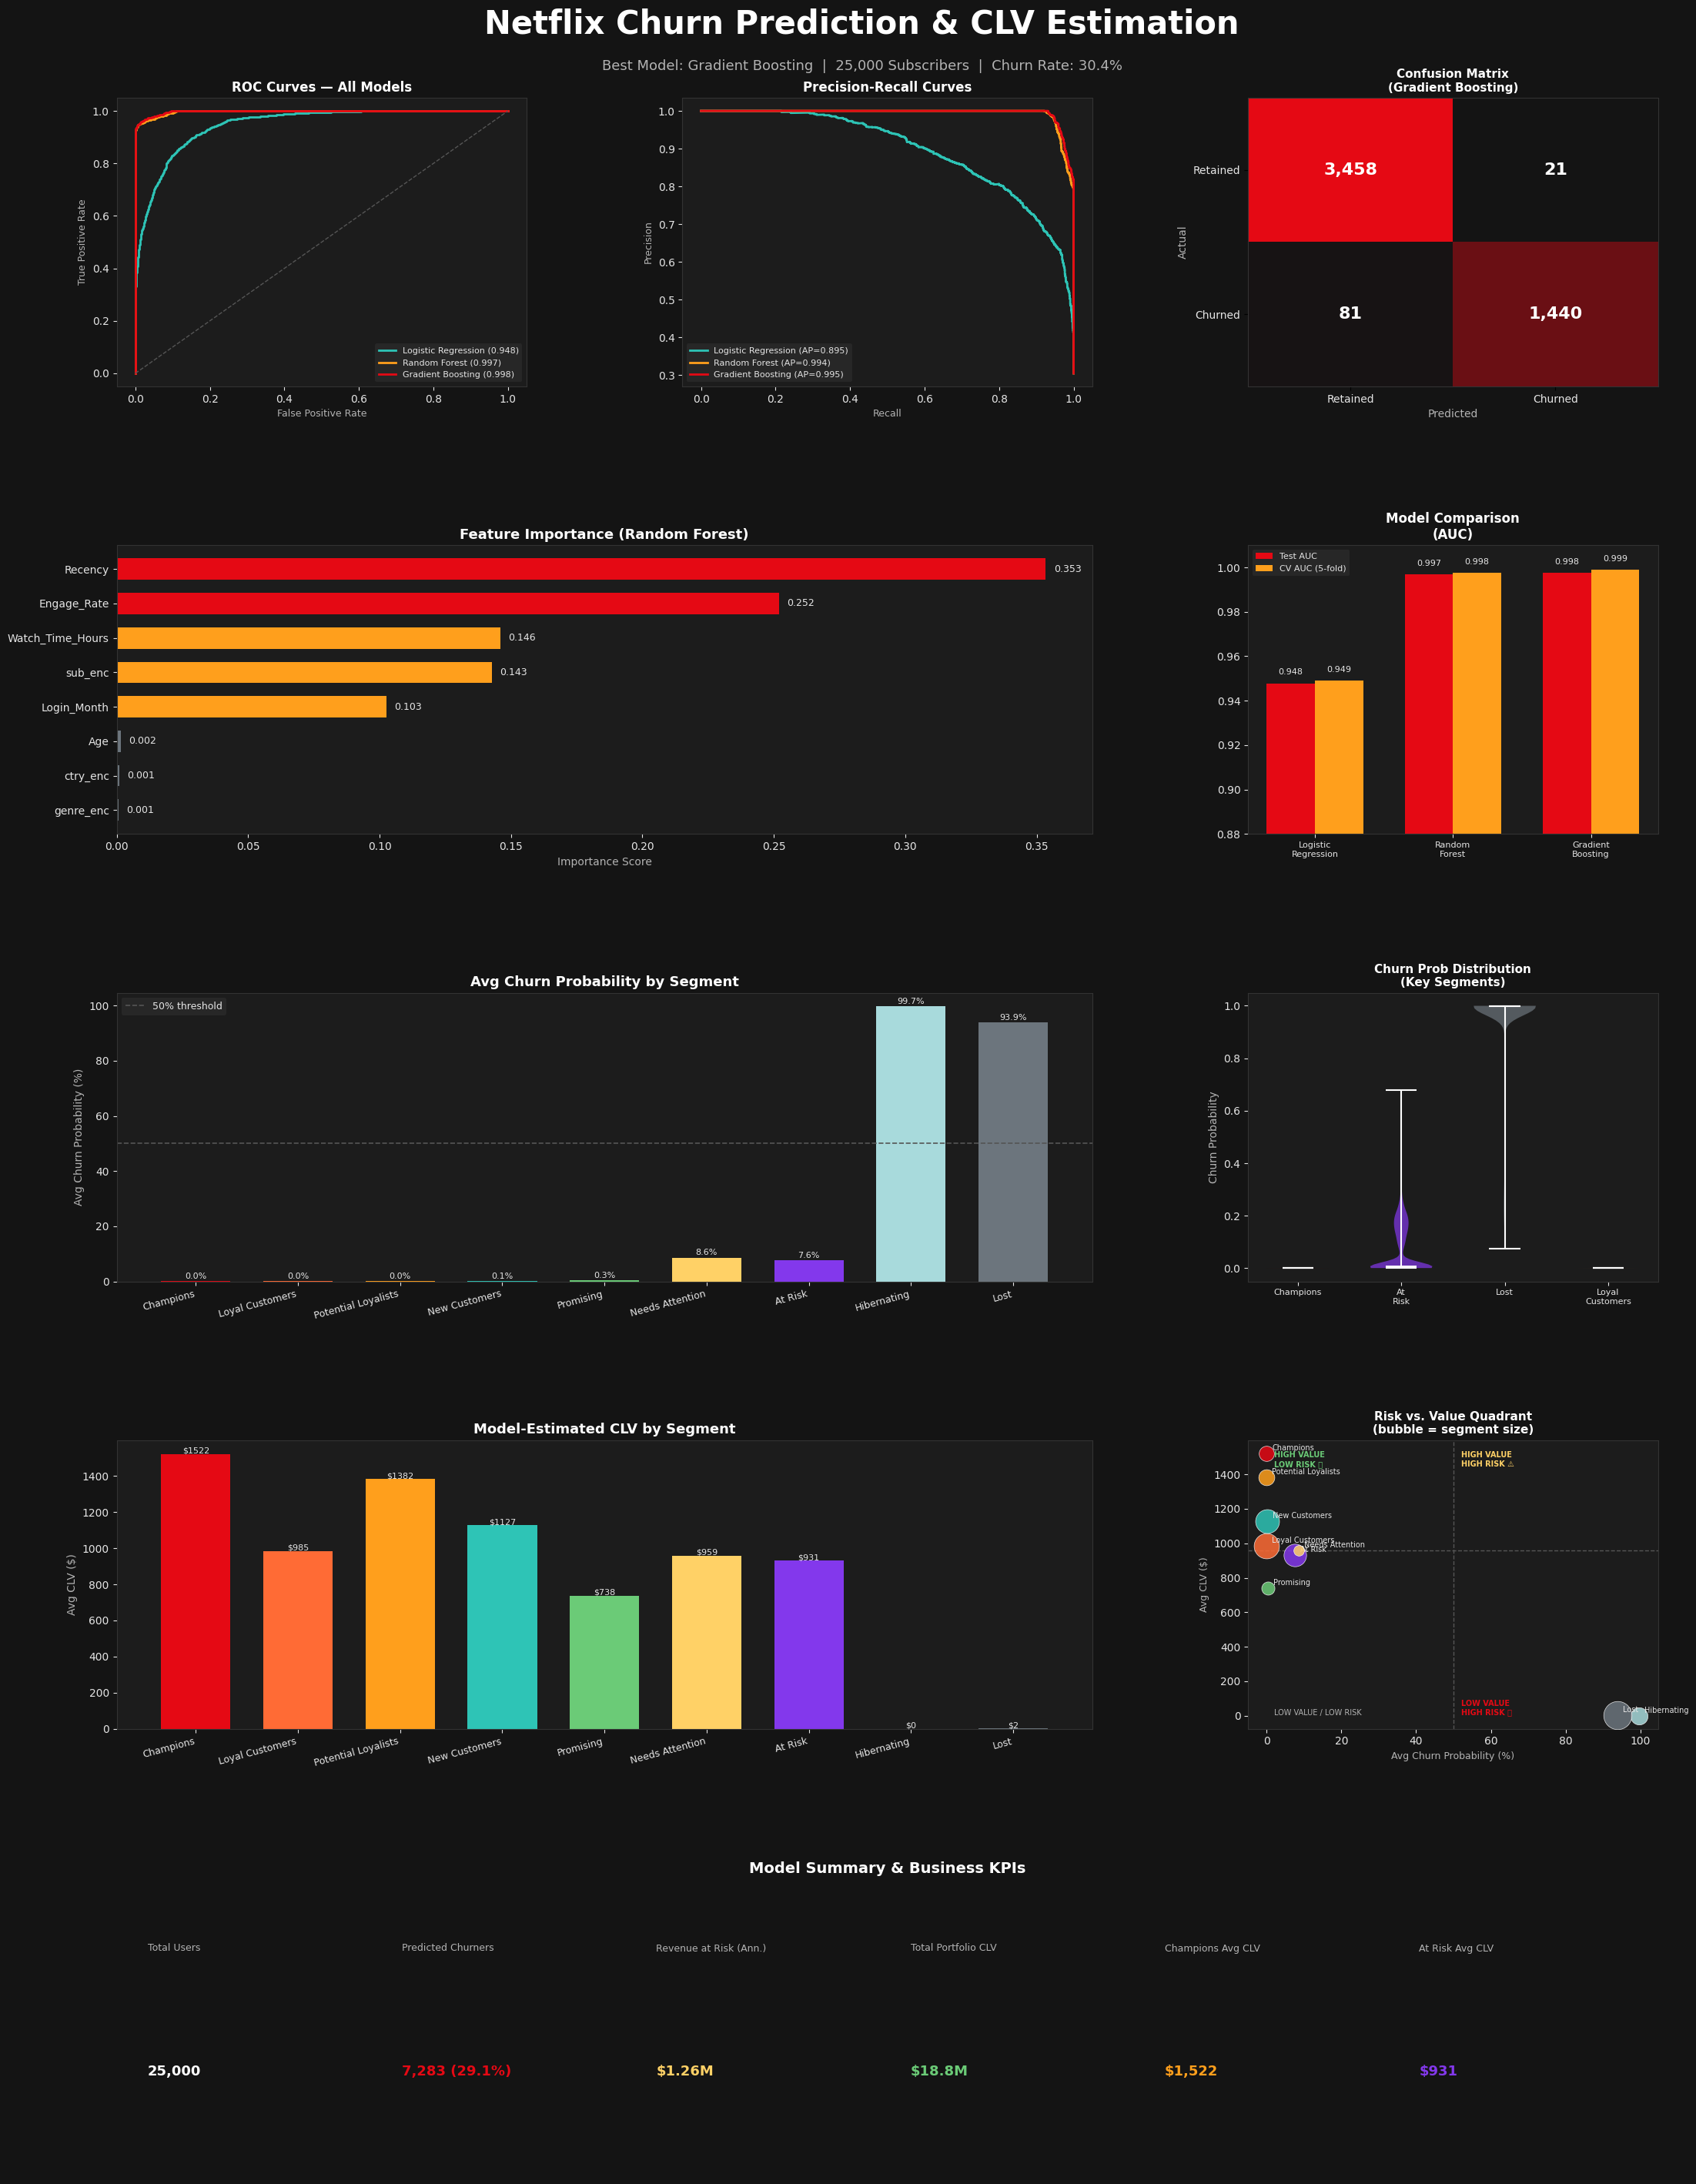

✅ Dashboard saved as netflix_churn_clv_dashboard.png


In [21]:
# ── CELL 13 · Churn + CLV Dashboard ──────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

MODEL_COLORS = {
    'Logistic Regression': '#2EC4B6',
    'Random Forest':       '#FF9F1C',
    'Gradient Boosting':   '#E50914',
}

fig = plt.figure(figsize=(22, 30), facecolor=NETFLIX_BLACK)
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.38,
                        left=0.06, right=0.97, top=0.94, bottom=0.04)

fig.text(0.5, 0.968, 'Netflix Churn Prediction & CLV Estimation',
         fontsize=30, fontweight='bold', ha='center', color=WHITE)
fig.text(0.5, 0.952,
         f'Best Model: {best_name}  |  25,000 Subscribers  |  Churn Rate: {df["Churned"].mean():.1%}',
         fontsize=13, ha='center', color=LIGHT_GRAY)

# Panel 1 — ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(DARK_GRAY)
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax1.plot(fpr, tpr, color=MODEL_COLORS[name], lw=2,
             label=f"{name} ({res['auc']:.3f})")
ax1.plot([0, 1], [0, 1], '--', color='#555555', lw=1)
ax1.set_xlabel('False Positive Rate', color=LIGHT_GRAY, fontsize=9)
ax1.set_ylabel('True Positive Rate',  color=LIGHT_GRAY, fontsize=9)
ax1.set_title('ROC Curves — All Models', color=WHITE, fontsize=12, fontweight='bold')
ax1.tick_params(colors=TEXT_MAIN)
ax1.legend(fontsize=8, facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN)
for sp in ax1.spines.values(): sp.set_color('#333333')

# Panel 2 — Precision-Recall
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(DARK_GRAY)
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax2.plot(rec, prec, color=MODEL_COLORS[name], lw=2,
             label=f"{name} (AP={res['ap']:.3f})")
ax2.set_xlabel('Recall',    color=LIGHT_GRAY, fontsize=9)
ax2.set_ylabel('Precision', color=LIGHT_GRAY, fontsize=9)
ax2.set_title('Precision-Recall Curves', color=WHITE, fontsize=12, fontweight='bold')
ax2.tick_params(colors=TEXT_MAIN)
ax2.legend(fontsize=8, facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN)
for sp in ax2.spines.values(): sp.set_color('#333333')

# Panel 3 — Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(DARK_GRAY)
cm   = confusion_matrix(y_test, results[best_name]['y_pred'])
cmap = LinearSegmentedColormap.from_list('netflix', ['#141414', '#E50914'])
ax3.imshow(cm, cmap=cmap, aspect='auto')
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Retained', 'Churned'], color=TEXT_MAIN, fontsize=10)
ax3.set_yticklabels(['Retained', 'Churned'], color=TEXT_MAIN, fontsize=10)
ax3.set_xlabel('Predicted', color=LIGHT_GRAY, fontsize=10)
ax3.set_ylabel('Actual',    color=LIGHT_GRAY, fontsize=10)
ax3.set_title(f'Confusion Matrix\n({best_name})', color=WHITE, fontsize=11, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                 color=WHITE, fontsize=16, fontweight='bold')
for sp in ax3.spines.values(): sp.set_color('#333333')

# Panel 4 — Feature Importance
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor(DARK_GRAY)
fi        = feat_imp.sort_values()
fi_colors = ['#E50914' if v > 0.15 else '#FF9F1C' if v > 0.08 else '#6C757D'
             for v in fi.values]
bars4 = ax4.barh(fi.index, fi.values, color=fi_colors, edgecolor='none', height=0.62)
for bar in bars4:
    ax4.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.3f}', va='center', color=TEXT_MAIN, fontsize=9)
ax4.set_title('Feature Importance (Random Forest)', color=WHITE, fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance Score', color=LIGHT_GRAY)
ax4.tick_params(colors=TEXT_MAIN)
for sp in ax4.spines.values(): sp.set_color('#333333')

# Panel 5 — Model Comparison
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(DARK_GRAY)
names_list = list(results.keys())
aucs = [results[n]['auc']    for n in names_list]
cvs  = [results[n]['cv_auc'] for n in names_list]
xp   = np.arange(len(names_list))
w    = 0.35
ax5.bar(xp - w/2, aucs, width=w, color='#E50914', label='Test AUC',        edgecolor='none')
ax5.bar(xp + w/2, cvs,  width=w, color='#FF9F1C', label='CV AUC (5-fold)', edgecolor='none')
for i, (a, c) in enumerate(zip(aucs, cvs)):
    ax5.text(i - w/2, a + 0.004, f'{a:.3f}', ha='center', color=TEXT_MAIN, fontsize=8)
    ax5.text(i + w/2, c + 0.004, f'{c:.3f}', ha='center', color=TEXT_MAIN, fontsize=8)
ax5.set_xticks(xp)
ax5.set_xticklabels([n.replace(' ', '\n') for n in names_list], color=TEXT_MAIN, fontsize=8)
ax5.set_ylim(0.88, 1.01)
ax5.set_title('Model Comparison\n(AUC)', color=WHITE, fontsize=12, fontweight='bold')
ax5.tick_params(colors=TEXT_MAIN)
ax5.legend(fontsize=8, facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN)
for sp in ax5.spines.values(): sp.set_color('#333333')

# Panel 6 — Churn Probability by Segment
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor(DARK_GRAY)
churn_seg = df.groupby('Segment')['Churn_Prob'].mean().reindex(seg_order).dropna()
bars6 = ax6.bar(range(len(churn_seg)), churn_seg.values * 100,
                color=[SEGMENT_COLORS[s] for s in churn_seg.index],
                edgecolor='none', width=0.68)
ax6.axhline(50, color='#555555', linestyle='--', lw=1.2, label='50% threshold')
for bar in bars6:
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', color=TEXT_MAIN, fontsize=8)
ax6.set_xticks(range(len(churn_seg)))
ax6.set_xticklabels(churn_seg.index, color=TEXT_MAIN, fontsize=9, rotation=15, ha='right')
ax6.set_ylabel('Avg Churn Probability (%)', color=LIGHT_GRAY)
ax6.set_title('Avg Churn Probability by Segment', color=WHITE, fontsize=13, fontweight='bold')
ax6.tick_params(colors=TEXT_MAIN)
ax6.legend(fontsize=9, facecolor=MID_GRAY, edgecolor='none', labelcolor=TEXT_MAIN)
for sp in ax6.spines.values(): sp.set_color('#333333')

# Panel 7 — Churn Probability Distribution (violin)
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(DARK_GRAY)
highlight_segs = ['Champions', 'At Risk', 'Lost', 'Loyal Customers']
for i, seg in enumerate(highlight_segs):
    vals = df[df['Segment'] == seg]['Churn_Prob'].values
    vp   = ax7.violinplot(vals, positions=[i], showmedians=True, widths=0.6)
    c    = SEGMENT_COLORS[seg]
    for pc in vp['bodies']:
        pc.set_facecolor(c); pc.set_alpha(0.7)
    for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
        if part in vp: vp[part].set_color(WHITE)
ax7.set_xticks(range(len(highlight_segs)))
ax7.set_xticklabels([s.replace(' ', '\n') for s in highlight_segs],
                    color=TEXT_MAIN, fontsize=8)
ax7.set_ylabel('Churn Probability', color=LIGHT_GRAY)
ax7.set_title('Churn Prob Distribution\n(Key Segments)', color=WHITE, fontsize=11, fontweight='bold')
ax7.tick_params(colors=TEXT_MAIN)
for sp in ax7.spines.values(): sp.set_color('#333333')

# Panel 8 — Model CLV by Segment
ax8 = fig.add_subplot(gs[3, :2])
ax8.set_facecolor(DARK_GRAY)
clv_seg = df.groupby('Segment')['CLV_Model'].mean().reindex(seg_order).dropna()
bars8   = ax8.bar(range(len(clv_seg)), clv_seg.values,
                  color=[SEGMENT_COLORS[s] for s in clv_seg.index],
                  edgecolor='none', width=0.68)
for bar in bars8:
    ax8.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'${bar.get_height():.0f}', ha='center', color=TEXT_MAIN, fontsize=8)
ax8.set_xticks(range(len(clv_seg)))
ax8.set_xticklabels(clv_seg.index, color=TEXT_MAIN, fontsize=9, rotation=15, ha='right')
ax8.set_ylabel('Avg CLV ($)', color=LIGHT_GRAY)
ax8.set_title('Model-Estimated CLV by Segment', color=WHITE, fontsize=13, fontweight='bold')
ax8.tick_params(colors=TEXT_MAIN)
for sp in ax8.spines.values(): sp.set_color('#333333')

# Panel 9 — Risk vs. Value Quadrant Scatter
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor(DARK_GRAY)
seg_stats = df.groupby('Segment').agg(
    Churn = ('Churn_Prob', 'mean'),
    CLV   = ('CLV_Model',  'mean'),
    Count = ('User_ID',    'count')
).reset_index()
for _, row in seg_stats.iterrows():
    seg = row['Segment']
    if seg not in SEGMENT_COLORS: continue
    ax9.scatter(row['Churn'] * 100, row['CLV'],
                s=row['Count'] / 8, color=SEGMENT_COLORS[seg],
                alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
    ax9.annotate(seg, (row['Churn'] * 100, row['CLV']),
                 textcoords='offset points', xytext=(5, 3),
                 color=TEXT_MAIN, fontsize=7)
ax9.axvline(50, color='#555555', linestyle='--', lw=1)
ax9.axhline(seg_stats['CLV'].median(), color='#555555', linestyle='--', lw=1)
ax9.set_xlabel('Avg Churn Probability (%)', color=LIGHT_GRAY, fontsize=9)
ax9.set_ylabel('Avg CLV ($)',              color=LIGHT_GRAY, fontsize=9)
ax9.set_title('Risk vs. Value Quadrant\n(bubble = segment size)',
              color=WHITE, fontsize=11, fontweight='bold')
ax9.tick_params(colors=TEXT_MAIN)
for sp in ax9.spines.values(): sp.set_color('#333333')
clv_max = seg_stats['CLV'].max(); clv_min = seg_stats['CLV'].min()
ax9.text(2,  clv_max * 0.95, 'HIGH VALUE\nLOW RISK ✅',  color='#6BCB77', fontsize=7, fontweight='bold')
ax9.text(52, clv_max * 0.95, 'HIGH VALUE\nHIGH RISK ⚠️', color='#FFD166', fontsize=7, fontweight='bold')
ax9.text(2,  clv_min + 5,    'LOW VALUE / LOW RISK',      color=LIGHT_GRAY, fontsize=7)
ax9.text(52, clv_min + 5,    'LOW VALUE\nHIGH RISK 🚨',   color='#E50914',  fontsize=7, fontweight='bold')

# Panel 10 — KPI Scorecard
ax10 = fig.add_subplot(gs[4, :])
ax10.set_facecolor(MID_GRAY)
ax10.axis('off')
pred_churn     = df['Predicted_Churn'].sum()
churn_rev_risk = (df[df['Predicted_Churn'] == 1]['Monthly_Spend'] * 12).sum()
avg_clv_champ  = df[df['Segment'] == 'Champions']['CLV_Model'].mean()
avg_clv_risk   = df[df['Segment'] == 'At Risk']['CLV_Model'].mean()
total_clv      = df['CLV_Model'].sum()
kpis = [
    ('Total Users',           f"{len(df):,}",                         WHITE),
    ('Predicted Churners',    f"{pred_churn:,} ({pred_churn/len(df):.1%})", '#E50914'),
    ('Revenue at Risk (Ann.)',f"${churn_rev_risk / 1e6:.2f}M",        '#FFD166'),
    ('Total Portfolio CLV',   f"${total_clv / 1e6:.1f}M",             '#6BCB77'),
    ('Champions Avg CLV',     f"${avg_clv_champ:,.0f}",               '#FF9F1C'),
    ('At Risk Avg CLV',       f"${avg_clv_risk:,.0f}",                '#8338EC'),
]
ax10.set_title('Model Summary & Business KPIs', color=WHITE, fontsize=14, fontweight='bold', pad=14)
for i, (label, value, color) in enumerate(kpis):
    x = 0.02 + i * 0.165
    ax10.text(x, 0.78, label, color=LIGHT_GRAY, fontsize=9, transform=ax10.transAxes)
    ax10.text(x, 0.35, value, color=color, fontsize=13, fontweight='bold',
              transform=ax10.transAxes)

plt.savefig('netflix_churn_clv_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=NETFLIX_BLACK)
plt.show()
print("✅ Dashboard saved as netflix_churn_clv_dashboard.png")

In [22]:
# ── CELL 14 · Download all outputs ───────────────────────────────────────
from google.colab import files
files.download('netflix_rfm_enriched.csv')
files.download('netflix_churn_clv_enriched.csv')
files.download('netflix_rfm_dashboard.png')
files.download('netflix_churn_clv_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>